In [1]:
!pip install mlxtend networkx
# mlxtend = Machine Learning Extensions (fpgrowth, association_rules)
# networkx = network/graph drawing library
print("Libraries installed successfully!")

In [2]:
# #import libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import seaborn as sns
# import networkx as nx
# import ast
# import os
# import warnings
# warnings.filterwarnings('ignore')
# from mlxtend.frequent_patterns import fpgrowth,association_rules
# from mlxtend.preprocessing import TransactionEncoder
# #mlxtend.frequent_patterns contains main MBA functions
# #fpgrowth()-runs the fpgrowth algorithm
# #association rules-converts the frequent itemsets into if-then rules
# #transactionencode=converts list format into true/false table
# print('All libraries imported successfully!')
%matplotlib inline
# %matplotlib inline makes all charts appear directly inside the notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import ast
import os
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Ensure output folder exists
os.makedirs('cognicart/outputs', exist_ok=True)

print('All libraries imported successfully!')

C:\Users\ishas\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ishas\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


All libraries imported successfully!


In [3]:
pip install numpy==1.26.4

In [4]:
import numpy as np
print(np.__version__)

1.26.4


In [5]:
#import libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import ast
import os
import warnings
warnings.filterwarnings('ignore')
from mlxtend.frequent_patterns import fpgrowth,association_rules
from mlxtend.preprocessing import TransactionEncoder
#mlxtend.frequent_patterns contains main MBA functions
#fpgrowth()-runs the fpgrowth algorithm
#association rules-converts the frequent itemsets into if-then rules
#transactionencode=converts list format into true/false table
print('All libraries imported successfully!')

All libraries imported successfully!


In [6]:
#load basket data from week 2
basket=pd.read_csv('cognicart/data/cleaned/basket_format.csv')
basket['Items']=basket['Items'].apply(ast.literal_eval)
#ast= abstract syntax trees module(built into python)
#literal_eval=safely evaluates a list that look like a python code(list)
#never use eval directly it is a security risk
print('Basket data loaded!')
print(f'Total Transactions:{len(basket)}')
print(f'sample basket:')
print(basket.head(5))
#check average basket size
basket['BasketSize']=basket['Items'].apply(len)
print(f"\nAverage items per transaction:{basket['BasketSize'].mean():.1f}")
print(f'Min items:{basket["BasketSize"].min()}')
print(f'Max items:{basket["BasketSize"].max()}')

Basket data loaded!
Total Transactions:4930
sample basket:
   TransactionID                                              Items
0              1               [Chips, Bread, Shampoo, Wheat Flour]
1              2  [Tomatosauce, Coffee, Chips, Waterbottle, Brea...
2              3  [Banana, Chips, Nuts, Tea, Biscuits, Bread, Ap...
3              4        [Oil, Chips, Biscuits, Cold Drink, Cookies]
4              5  [Tomato, Oats, Chips, Bread, Soap, Tea, Cold D...

Average items per transaction:5.6
Min items:3
Max items:16


In [7]:
#encode transactions[convert to one hot format]
#fpgrowth cannnot read list directly
#it needs a True/False table called one-hot encoding
#true-product bought ,false-product is not bought
transactions=basket['Items'].tolist()
#tolist-convert pandas into plain python list
encoder=TransactionEncoder()
encoded_array=encoder.fit(transactions).transform(transactions)
#fit=learns all unique product name from our transaction
df_encoded=pd.DataFrame(encoded_array,columns=encoder.columns_)
#convert numpy array to pandas dataframe
print("encoding complete!")
print(f"shape:{df_encoded.shape}")
print(f"Unique Products:{len(encoder.columns_)}")
print("\nFirst 3 rows(showing 8columns):")
print(df_encoded.iloc[:3,:8])


encoding complete!
shape:(4930, 43)
Unique Products:43

First 3 rows(showing 8columns):
   Apple  Banana  Biscuit  Biscuits  Bread  Brown Bread  Butter  Carrot
0  False   False    False     False   True        False   False   False
1  False   False    False      True   True        False   False   False
2   True    True    False      True   True        False   False   False


In [8]:
#run fp growth algorithm
#support=how often an itemset appear in all transaction
#formula=transaction containing(A)/total transactions:support(A)
print("Runing FP-growth algorithm...")
print("This may take 30-60sec.please wait..")
frequent_itemsets=fpgrowth(
    df_encoded,
    min_support=0.005,
    use_colnames=True)
#minsupport means only itemset that appears in at least in at least 2% of all transaction
#fpgrowth() returns dataframe with columns
#itemsets:frozenset of products in this combination
#frozenset=like a python set but immutable(cannot be changed)
#example:frozenset({'bread','butter'})
frequent_itemsets['itemset_length']=frequent_itemsets['itemsets'].apply(len)
print(f'\nFP-Growth complete!')
print(f'Total frequent itemsets found:{len(frequent_itemsets)}')
print(f'\nBreakdown by itemset size:')
print(frequent_itemsets['itemset_length'].value_counts().sort_index())
print(f'\n Top 10 most frequent itemsets:')
print(frequent_itemsets.sort_values('support', ascending=False).head(10).to_string())

Runing FP-growth algorithm...
This may take 30-60sec.please wait..

FP-Growth complete!
Total frequent itemsets found:2077

Breakdown by itemset size:
itemset_length
1     43
2    744
3    953
4    306
5     31
Name: count, dtype: int64

 Top 10 most frequent itemsets:
      support                  itemsets  itemset_length
0    0.395943        frozenset({Bread})               1
18   0.372008         frozenset({Milk})               1
13   0.268763          frozenset({Oil})               1
4    0.264503          frozenset({Tea})               1
40   0.219473        frozenset({Onion})               1
1    0.218864        frozenset({Chips})               1
5    0.209128     frozenset({Biscuits})               1
6    0.208519   frozenset({Cold Drink})               1
34   0.182353         frozenset({Rice})               1
856  0.180325  frozenset({Bread, Milk})               2


In [9]:
#generate association rules
#now we convert frequent itemsets into if--> then rules
rules=association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.1)
rules=rules.sort_values('lift',ascending=False).reset_index(drop=True)
rules['antecedents_str']=rules['antecedents'].apply(lambda x:', '.join(list(x)))
rules['consequents_str']=rules['consequents'].apply(lambda x:', '.join(list(x)))
print(f'Total association rules generated:{len(rules)}')
print(f'\nTop 15 rules by Lift:')
display_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
print(rules[display_cols].head(15).to_string())
#save rules to csv
rules.to_csv('cognicart/data/cleaned/association_rules.csv',index=False)
print('\nRules saved to cognicart/data/cleaned/association_rules.csv')

Total association rules generated:6341

Top 15 rules by Lift:
                   antecedents_str                 consequents_str   support  confidence      lift
0                   Popcorn, Chips  Chocolate, Cold Drink, Namkeen  0.021298    0.337621  9.298712
1   Chocolate, Cold Drink, Namkeen                  Popcorn, Chips  0.021298    0.586592  9.298712
2                   Chips, Namkeen  Chocolate, Popcorn, Cold Drink  0.021298    0.329154  9.220041
3   Chocolate, Popcorn, Cold Drink                  Chips, Namkeen  0.021298    0.596591  9.220041
4                 Chocolate, Chips    Popcorn, Cold Drink, Namkeen  0.021298    0.352349  9.094662
5     Popcorn, Cold Drink, Namkeen                Chocolate, Chips  0.021298    0.549738  9.094662
6        Chocolate, Chips, Namkeen             Popcorn, Cold Drink  0.021298    0.538462  9.029304
7              Popcorn, Cold Drink       Chocolate, Chips, Namkeen  0.021298    0.357143  9.029304
8     Chocolate, Chips, Cold Drink             

In [10]:
#Filter strong rules
#not all rules are equally useful.We apply stricter filters to find only strong,high quality rules
#good rule=high support+high confidence+lift>1
#filter rule:confidence>35% and lift>1.2
strong_rules=rules[
(rules['confidence']>=0.1)&
(rules['lift']>=1.0)].copy()
print(f'strong rules(confidence>=35%,lift>=1.2):{len(strong_rules)}')
print(f'\nTop 20 strong rules:')
print(strong_rules[display_cols].head(20).to_string())
print(f'\nRule Statistics:')
print(f'Average Support:{rules['support'].mean():.3f}')
print(f'Average Confidence:{rules['confidence'].mean():.3f}')
print(f'Average Lift:{rules['lift'].mean():.3f}')
print(f'Max Lift:{rules['lift'].max():.3f}')

strong rules(confidence>=35%,lift>=1.2):5383

Top 20 strong rules:
                   antecedents_str                 consequents_str   support  confidence      lift
0                   Popcorn, Chips  Chocolate, Cold Drink, Namkeen  0.021298    0.337621  9.298712
1   Chocolate, Cold Drink, Namkeen                  Popcorn, Chips  0.021298    0.586592  9.298712
2                   Chips, Namkeen  Chocolate, Popcorn, Cold Drink  0.021298    0.329154  9.220041
3   Chocolate, Popcorn, Cold Drink                  Chips, Namkeen  0.021298    0.596591  9.220041
4                 Chocolate, Chips    Popcorn, Cold Drink, Namkeen  0.021298    0.352349  9.094662
5     Popcorn, Cold Drink, Namkeen                Chocolate, Chips  0.021298    0.549738  9.094662
6        Chocolate, Chips, Namkeen             Popcorn, Cold Drink  0.021298    0.538462  9.029304
7              Popcorn, Cold Drink       Chocolate, Chips, Namkeen  0.021298    0.357143  9.029304
8     Chocolate, Chips, Cold Drink        

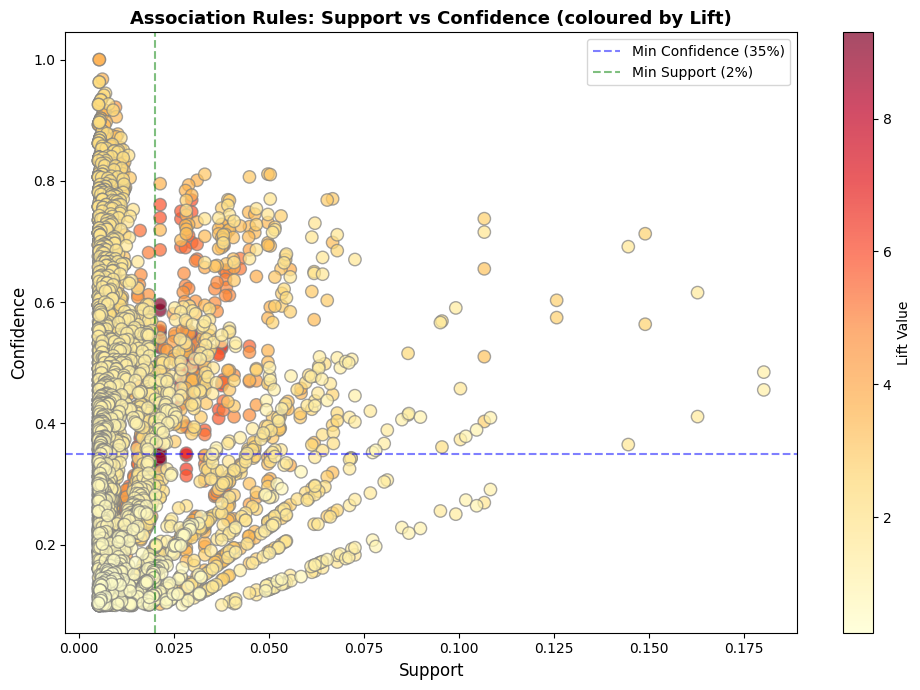

Scatter plot saved!


In [11]:
#visualization1:support vs confidence scatter plot
#each dot=one association rule
plt.figure(figsize=(10,7))
scatter=plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='grey',
    s=80)
plt.colorbar(scatter,label='Lift Value')
plt.xlabel('Support',fontsize=12)
plt.ylabel('Confidence',fontsize=12)
plt.title('Association Rules: Support vs Confidence (coloured by Lift)', fontsize=13, fontweight='bold')
#add refrence lines to highlight strong rules zone
plt.axhline(y=0.35, color='blue', linestyle='--', alpha=0.5, label='Min Confidence (35%)')
plt.axvline(x=0.02, color='green', linestyle='--', alpha=0.5, label='Min Support (2%)')
# axhline = horizontal line (h = horizontal)
# axvline = vertical line (v = vertical)
# linestyle='--' = dashed line

plt.legend()
plt.tight_layout()
plt.savefig('cognicart/outputs/week3_scatter.png', dpi=150)
plt.show()
print('Scatter plot saved!')

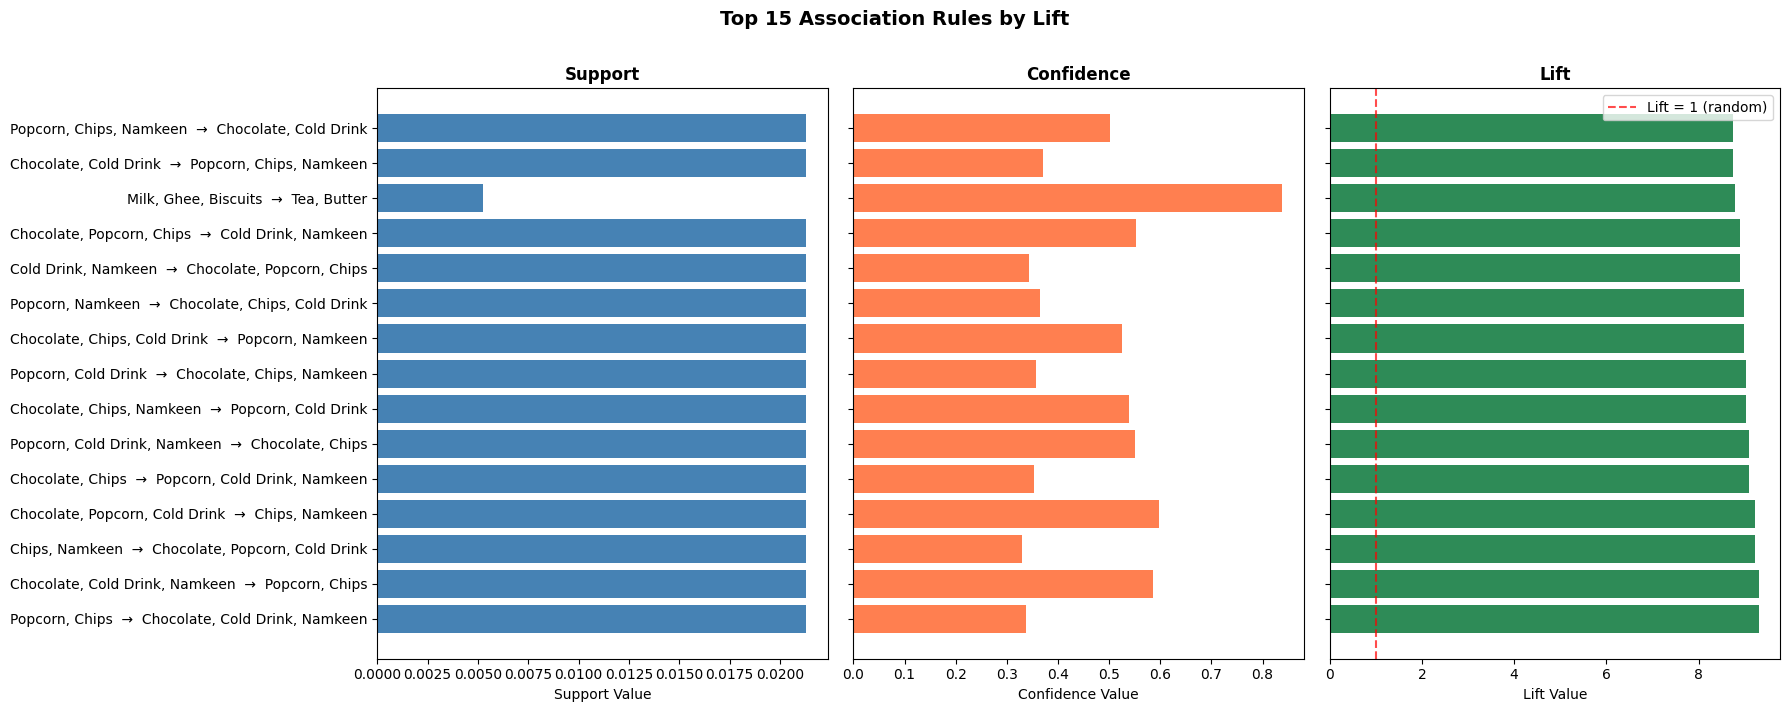

Top rules chart saved!


In [12]:
# ============================================================
# CELL 9 — Visualisation 2: Top Rules Bar Chart
#
# Shows top 15 rules clearly as horizontal bars.
# Rule label = 'Product A → Product B'
# Bar length = Lift value (longer = stronger association)
# ============================================================

# Pick top 15 rules by lift for display
top15 = strong_rules.head(15).copy()
top15['rule_label'] = top15['antecedents_str'] + '  →  ' + top15['consequents_str']
# Creates a readable label: 'Bread, Butter  →  Milk'

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
# Creates 3 side-by-side charts: Support, Confidence, Lift

# Chart 1: Support
bars1 = axes[0].barh(top15['rule_label'], top15['support'], color='steelblue')
axes[0].set_title('Support', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Support Value')
# barh = horizontal bar chart (h = horizontal)
# First arg = labels on y-axis
# Second arg = bar lengths

# Chart 2: Confidence
bars2 = axes[1].barh(top15['rule_label'], top15['confidence'], color='coral')
axes[1].set_title('Confidence', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Confidence Value')
axes[1].set_yticklabels([])     # hide y-axis labels (already shown in chart 1)

# Chart 3: Lift
bars3 = axes[2].barh(top15['rule_label'], top15['lift'], color='seagreen')
axes[2].set_title('Lift', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Lift Value')
axes[2].set_yticklabels([])     # hide y-axis labels
axes[2].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Lift = 1 (random)')
# Lift=1 reference line: rules to the right of this are actually useful
axes[2].legend()

plt.suptitle('Top 15 Association Rules by Lift', fontsize=14, fontweight='bold', y=1.01)
# suptitle = super title (title for the whole figure, above all subplots)
# y=1.01 = position above the charts

plt.tight_layout()
plt.savefig('cognicart/outputs/week3_top_rules.png', dpi=150, bbox_inches='tight')
# bbox_inches='tight' = crop whitespace around figure edges
plt.show()
print('Top rules chart saved!')

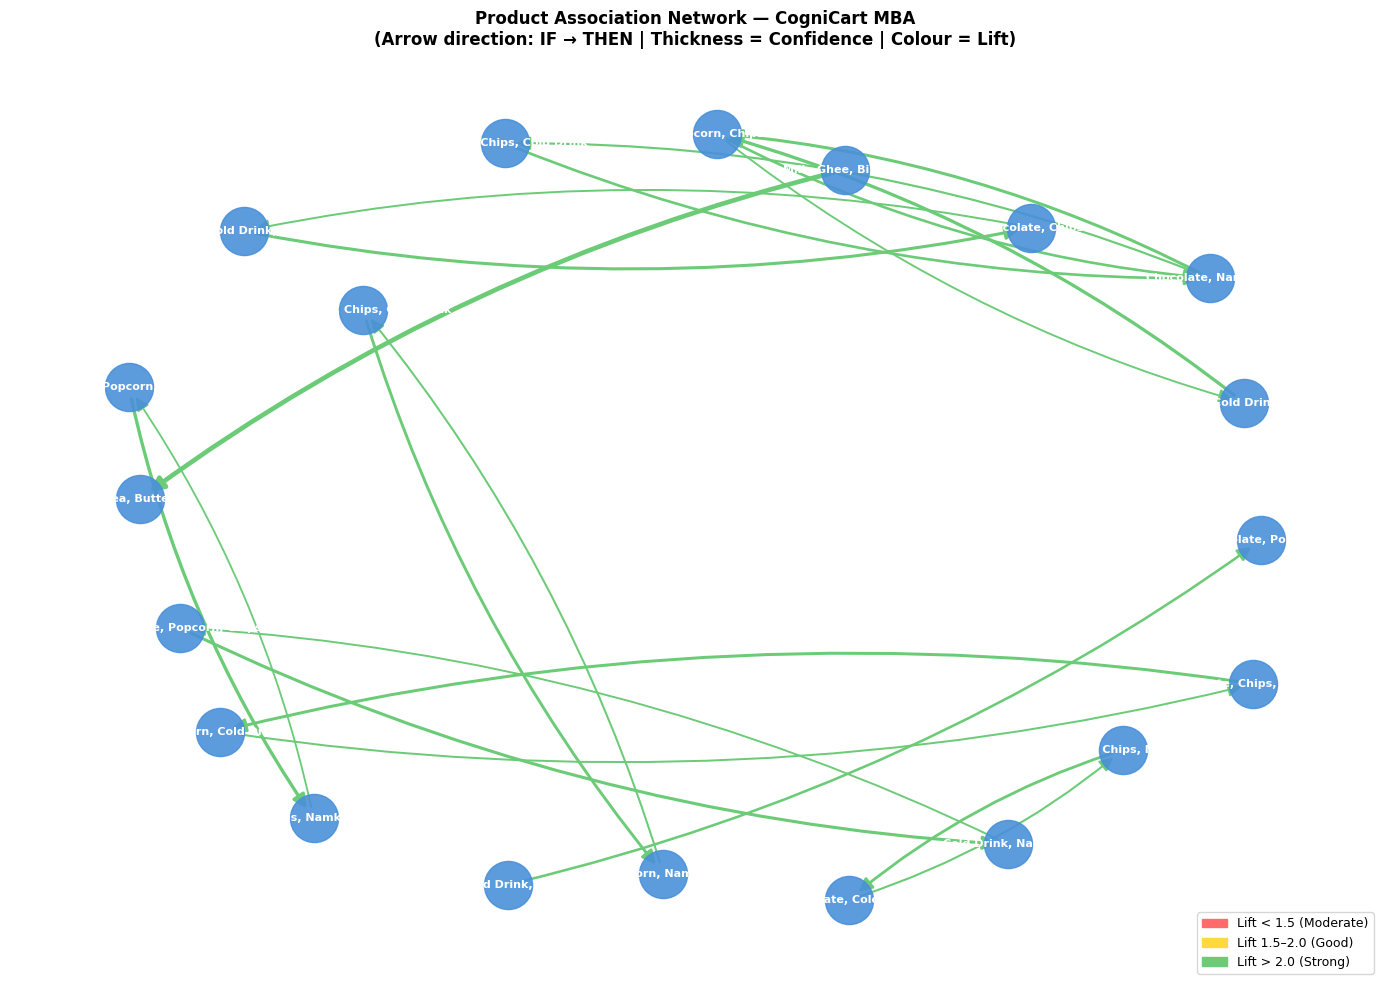

Network graph saved!


In [13]:
# ============================================================
# CELL 10 — Visualisation 3: Network Graph
#
# This is the most impressive visualisation in CogniCart!
# Products = nodes (circles)
# Rules = edges (arrows between circles)
# Arrow direction = IF product A (tail) → THEN product B (head)
# Arrow thickness = confidence of the rule
# Arrow colour = lift value
# ============================================================

# Use top rules only to avoid a cluttered graph
top_rules_for_graph = strong_rules.head(20).copy()

# Create a directed graph
G = nx.DiGraph()
# nx.DiGraph = Directed Graph (arrows have direction, unlike undirected graph)
# Directed = IF Bread → Butter is different from IF Butter → Bread

# Add edges (arrows) to graph from our rules
for _, row in top_rules_for_graph.iterrows():
    antecedent = row['antecedents_str']    # IF side
    consequent = row['consequents_str']    # THEN side
    G.add_edge(
        antecedent,
        consequent,
        weight=row['confidence'],   # stored as edge attribute
        lift=row['lift']
    )
# iterrows() = loops through DataFrame row by row
# _ = we ignore the index (convention: _ means 'unused variable')
# G.add_edge(A, B) = adds an arrow from A to B in the graph
# weight=, lift= = extra data stored on each edge (we use these for styling)

# Calculate positions for nodes using spring layout
pos = nx.spring_layout(G, seed=42, k=2)
# spring_layout = simulates springs between nodes, pushes them apart nicely
# seed=42 = fixed random seed so layout is same every run
# k=2 = spring constant (higher = nodes spread further apart)

# Extract edge attributes for styling
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
edge_lifts = [G[u][v]['lift'] for u, v in G.edges()]
# List comprehension: [expression for each_edge in all_edges]
# G[u][v]['weight'] = get the 'weight' attribute of edge from u to v

# Draw the graph
plt.figure(figsize=(14, 10))

# Draw nodes (product circles)
nx.draw_networkx_nodes(
    G, pos,
    node_color='#4A90D9',     # blue colour
    node_size=1200,            # circle size
    alpha=0.9
)

# Draw node labels (product names inside circles)
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_color='white',
    font_weight='bold'
)

# Draw edges (arrows between products)
# Colour edges by lift: higher lift = more yellow/green
edge_colors = ['#FF6B6B' if l < 1.5 else '#FFD93D' if l < 2.0 else '#6BCB77'
               for l in edge_lifts]
# Conditional list comprehension:
# Red (#FF6B6B) if lift < 1.5 (moderate rule)
# Yellow (#FFD93D) if lift < 2.0 (good rule)
# Green (#6BCB77) if lift >= 2.0 (strong rule)

nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_colors,
    width=[w * 4 for w in edge_weights],   # thicker arrow = higher confidence
    arrows=True,
    arrowsize=20,
    connectionstyle='arc3,rad=0.1'         # slight curve on arrows (looks better)
)

# Manual legend
legend_handles = [
    mpatches.Patch(color='#FF6B6B', label='Lift < 1.5 (Moderate)'),
    mpatches.Patch(color='#FFD93D', label='Lift 1.5–2.0 (Good)'),
    mpatches.Patch(color='#6BCB77', label='Lift > 2.0 (Strong)')
]
plt.legend(handles=legend_handles, loc='lower right', fontsize=9)
# mpatches.Patch = a coloured rectangle for the legend

plt.title('Product Association Network — CogniCart MBA\n(Arrow direction: IF → THEN | Thickness = Confidence | Colour = Lift)',
          fontsize=12, fontweight='bold')
plt.axis('off')    # hides x and y axes (not needed for network graphs)
plt.tight_layout()
plt.savefig('cognicart/outputs/week3_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('Network graph saved!')

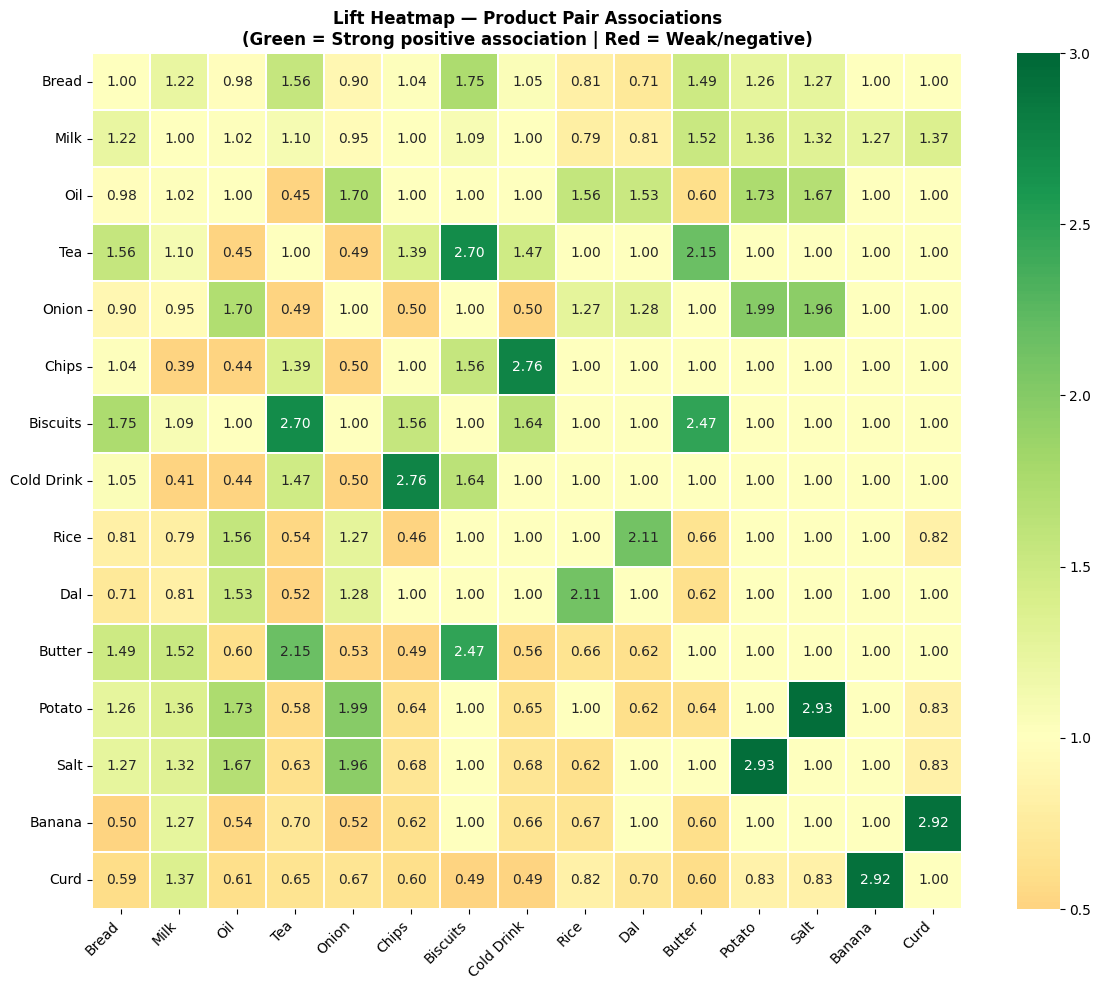

Lift heatmap saved!


In [14]:
# ============================================================
# CELL 11 — Visualisation 4: Lift Heatmap
#
# Shows lift between product pairs as a colour grid.
# Darker colour = stronger association between two products.
# Great for spotting which product CATEGORIES go together.
# ============================================================

# Get top 15 most frequent single products for the heatmap
single_items = frequent_itemsets[frequent_itemsets['itemset_length'] == 1].copy()
single_items['product'] = single_items['itemsets'].apply(lambda x: list(x)[0])
top_products = single_items.nlargest(15, 'support')['product'].tolist()
# nlargest(15, 'support') = get the 15 rows with highest support values

# Build a lift matrix for these products
lift_matrix = pd.DataFrame(index=top_products, columns=top_products, dtype=float)
lift_matrix = lift_matrix.fillna(1.0)    # default = 1.0 (no association)

# Fill matrix with actual lift values from rules
for _, row in rules.iterrows():
    ant = row['antecedents_str']
    con = row['consequents_str']
    if ant in top_products and con in top_products:
        lift_matrix.loc[ant, con] = row['lift']
        # .loc[row_label, col_label] = access cell by row and column names

lift_matrix = lift_matrix.astype(float)   # ensure numeric type for heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(
    lift_matrix,
    annot=True,           # show numbers inside each cell
    fmt='.2f',            # format: 2 decimal places
    cmap='RdYlGn',        # colour: Red (low lift) → Yellow → Green (high lift)
    center=1.0,           # centre the colour scale at lift=1.0
    linewidths=0.3,
    vmin=0.5, vmax=3.0    # fix colour scale range for clarity
)
# center=1.0 = lift=1 is white/neutral, above 1 = green, below 1 = red
# vmin/vmax = minimum and maximum values for the colour scale

plt.title('Lift Heatmap — Product Pair Associations\n(Green = Strong positive association | Red = Weak/negative)',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')   # rotate x-axis labels for readability
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cognicart/outputs/week3_lift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Lift heatmap saved!')

In [15]:
# ============================================================
# CELL 12 — Build a Simple Recommendation Function
#
# Real-world use of MBA: Given items in cart → recommend next item.
# This is what Amazon, Flipkart, Swiggy Instamart do!
#
# This is a great function to show in interviews and demos.
# ============================================================

def get_recommendations(cart_items, rules_df, top_n=5):
    """
    Given a list of items in cart, recommend products the customer might also buy.
    
    Parameters:
    -----------
    cart_items : list  — products currently in the cart
    rules_df   : DataFrame — association rules from FP-Growth
    top_n      : int   — how many recommendations to return
    
    Returns:
    --------
    DataFrame — recommended products with confidence and lift scores
    """
    recommendations = []

    for _, rule in rules_df.iterrows():
        # Check if the rule's antecedent (IF side) is a subset of our cart
        antecedent_set = set(rule['antecedents'])   # convert frozenset to set
        cart_set = set(cart_items)

        if antecedent_set.issubset(cart_set):
            # .issubset() = True if ALL items in antecedent are in our cart
            # Example: if antecedent = {Bread, Butter} and cart = {Bread, Butter, Milk}
            # then issubset = True (Bread and Butter ARE in the cart)

            for item in rule['consequents']:
                # For each recommended item in the THEN side of the rule
                if item not in cart_set:   # only recommend items NOT already in cart
                    recommendations.append({
                        'Recommended Item': item,
                        'Because you have': ', '.join(list(antecedent_set)),
                        'Confidence': round(rule['confidence'], 3),
                        'Lift': round(rule['lift'], 3)
                    })

    if not recommendations:
        return 'No recommendations found for this cart.'

    # Convert to DataFrame, remove duplicates, sort by lift
    rec_df = pd.DataFrame(recommendations)
    rec_df = rec_df.drop_duplicates(subset='Recommended Item')   # keep best rule per item
    rec_df = rec_df.sort_values('Lift', ascending=False).head(top_n).reset_index(drop=True)

    return rec_df


# ---- TEST THE FUNCTION ----

print('=' * 55)
print('COGNICART RECOMMENDATION ENGINE — DEMO')
print('=' * 55)

# Test 1
cart1 = ['Milk', 'Bread']
print(f'\nCart: {cart1}')
print('Recommendations:')
print(get_recommendations(cart1, rules))

# Test 2
cart2 = ['Rice', 'Dal']
print(f'\nCart: {cart2}')
print('Recommendations:')
print(get_recommendations(cart2, rules))

# Test 3 — try with your own cart!
cart3 = ['Tea', 'Biscuits']
print(f'\nCart: {cart3}')
print('Recommendations:')
print(get_recommendations(cart3, rules))

COGNICART RECOMMENDATION ENGINE — DEMO

Cart: ['Milk', 'Bread']
Recommendations:
  Recommended Item Because you have  Confidence   Lift
0              Tea      Bread, Milk       0.183  2.747
1           Butter      Bread, Milk       0.183  2.747
2         Biscuits      Bread, Milk       0.183  2.747
3       Cold Drink            Bread       0.130  1.817
4            Chips            Bread       0.129  1.806

Cart: ['Rice', 'Dal']
Recommendations:
  Recommended Item Because you have  Confidence   Lift
0           Spices        Rice, Dal       0.136  3.448
1           Tomato        Rice, Dal       0.136  3.448
2             Ghee        Rice, Dal       0.121  3.129
3              Oil        Rice, Dal       0.133  2.750
4            Onion        Rice, Dal       0.115  2.604

Cart: ['Tea', 'Biscuits']
Recommendations:
  Recommended Item Because you have  Confidence   Lift
0            Bread         Biscuits       0.135  3.554
1            Chips         Biscuits       0.135  3.554
2       Co

In [16]:
# ============================================================
# CELL 13 — Week 3 Summary
# ============================================================

print('=' * 55)
print('WEEK 3 COMPLETE!')
print('=' * 55)
print()
print('What you built this week:')
print('  FP-Growth algorithm on your own supermarket data')
print(f'  Frequent itemsets found:    {len(frequent_itemsets)}')
print(f'  Association rules generated: {len(rules)}')
print(f'  Strong rules (quality filtered): {len(strong_rules)}')
print()
print('Key metrics of your rules:')
print(f'  Best Lift:       {rules["lift"].max():.3f}')
print(f'  Best Confidence: {rules["confidence"].max():.3f}')
print(f'  Best Support:    {rules["support"].max():.3f}')
print()
print('Files saved:')
print('  cognicart/data/cleaned/association_rules.csv')
print('  cognicart/outputs/week3_scatter.png')
print('  cognicart/outputs/week3_top_rules.png')
print('  cognicart/outputs/week3_network_graph.png')
print('  cognicart/outputs/week3_lift_heatmap.png')
print()
print('Interview talking points from this week:')
print('  Support = how common is this pattern')
print('  Confidence = how reliable is the IF-THEN rule')
print('  Lift = how much stronger than random chance')
print('  FP-Growth is faster than Apriori (no candidate generation)')
print()
print('Next Week: K-Means Clustering for Customer Segmentation!')

WEEK 3 COMPLETE!

What you built this week:
  FP-Growth algorithm on your own supermarket data
  Frequent itemsets found:    2077
  Association rules generated: 6341
  Strong rules (quality filtered): 5383

Key metrics of your rules:
  Best Lift:       9.299
  Best Confidence: 1.000
  Best Support:    0.180

Files saved:
  cognicart/data/cleaned/association_rules.csv
  cognicart/outputs/week3_scatter.png
  cognicart/outputs/week3_top_rules.png
  cognicart/outputs/week3_network_graph.png
  cognicart/outputs/week3_lift_heatmap.png

Interview talking points from this week:
  Support = how common is this pattern
  Confidence = how reliable is the IF-THEN rule
  Lift = how much stronger than random chance
  FP-Growth is faster than Apriori (no candidate generation)

Next Week: K-Means Clustering for Customer Segmentation!
